---

# CHAPTER 1: GETTING TO KNOW A DATASET



<br><br>

---
---

## Lesson 1: Initial Exploration



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<br><br>

---

### A first Look of the DataFrame

In [2]:
# Dataframe of the lesson
df = pd.read_csv('Resources/clean_books.csv')
df.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens


<br><br>

---

### Getting More Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    object 
 1   author  350 non-null    object 
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 13.8+ KB


<br><br>

---

### A Closer look at the Categorical Columns

In [4]:
df.genre.value_counts()

genre
Non Fiction    179
Fiction        131
Childrens       40
Name: count, dtype: int64

<br><br>

---

### Describing Numerical Columns

In [5]:
df.describe()

,rating,year
count,350.000000,350.000000
mean,4.608571,2013.508571
std,0.226941,3.284711
min,3.300000,2009.000000
25%,4.500000,2010.000000
50%,4.600000,2013.000000
75%,4.800000,2016.000000
max,4.900000,2019.000000


<br><br>

---

### Visualizing Numerical Data


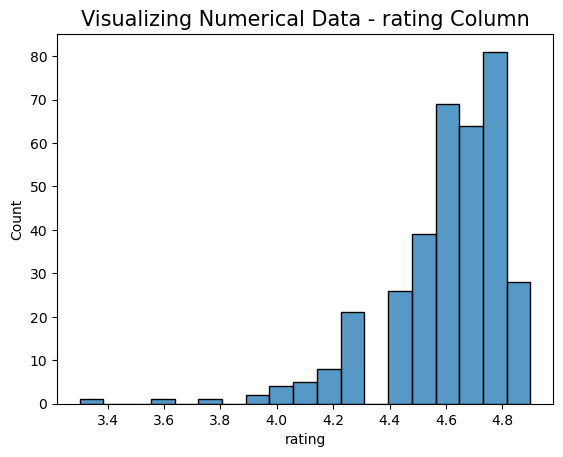

In [6]:
sns.histplot(data=df, x='rating')
plt.title('Visualizing Numerical Data - rating Column', fontsize=15)
plt.show()

<br><br>

---

### Adjusting "bin width"

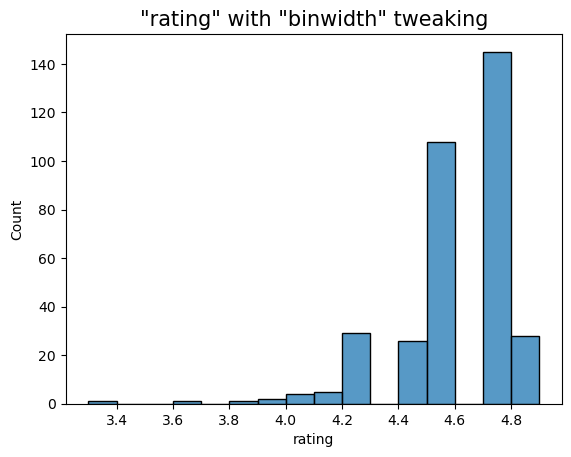

In [7]:
sns.histplot(data=df, x='rating', binwidth=0.1)
plt.title('"rating" with "binwidth" tweaking', fontsize=15)
plt.show()

<br><br>

---
---

## Lesson 2: Data Validation

<br><br>

---

### Validating Data Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    object 
 1   author  350 non-null    object 
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 13.8+ KB


In [9]:
df.dtypes

name       object
author     object
rating    float64
year        int64
genre      object
dtype: object

<br><br>

---

### Updating Data Types

In [10]:
df['year'] = df['year'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    object 
 1   author  350 non-null    object 
 2   rating  350 non-null    float64
 3   year    350 non-null    float64
 4   genre   350 non-null    object 
dtypes: float64(2), object(3)
memory usage: 13.8+ KB


In [11]:
# Note that 'year' must be an integer, not a float
df['year'] = df['year'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    object 
 1   author  350 non-null    object 
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 13.8+ KB


<br><br>

---

### Validating Categorical Data

In [12]:
# Positive Filtering
df.genre.isin(['Fiction', 'Non Fiction'])

0       True
1       True
2       True
3       True
4      False
       ...  
345     True
346     True
347     True
348     True
349    False
Name: genre, Length: 350, dtype: bool

In [13]:
# Not Filtering
~df.genre.isin(['Fiction', 'Non Fiction'])

0      False
1      False
2      False
3      False
4       True
       ...  
345    False
346    False
347    False
348    False
349     True
Name: genre, Length: 350, dtype: bool

In [14]:
# Filtering a DataFrame
df[df.genre.isin(['Fiction', 'Non Fiction'])]

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,2011,Fiction
...,...,...,...,...,...
344,Whose Boat Is This Boat?: Comments That Don't ...,The Staff of The Late Show with,4.6,2018,Non Fiction
345,Wild: From Lost to Found on the Pacific Crest ...,Cheryl Strayed,4.4,2012,Non Fiction
346,Winter of the World: Book Two of the Century T...,Ken Follett,4.5,2012,Fiction
347,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,2010,Non Fiction


<br><br>

---

### Validating Numerical Data


In [15]:
df.select_dtypes('number').head()

,rating,year
0,4.7,2016
1,4.6,2011
2,4.7,2018
3,4.7,2017
4,4.8,2019


In [16]:
df.select_dtypes('float').head()

,rating
0,4.7
1,4.6
2,4.7
3,4.7
4,4.8


In [17]:
df.select_dtypes('int').head()

,year
0,2016
1,2011
2,2018
3,2017
4,2019


In [18]:
df.select_dtypes('object').head()

,name,author,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,Non Fiction
1,11/22/63: A Novel,Stephen King,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,Non Fiction
3,1984 (Signet Classics),George Orwell,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,Childrens


In [19]:
df.select_dtypes('category').head()

""
0
1
2
3
4


   - Min Year: 2009
   - Max Year: 2019


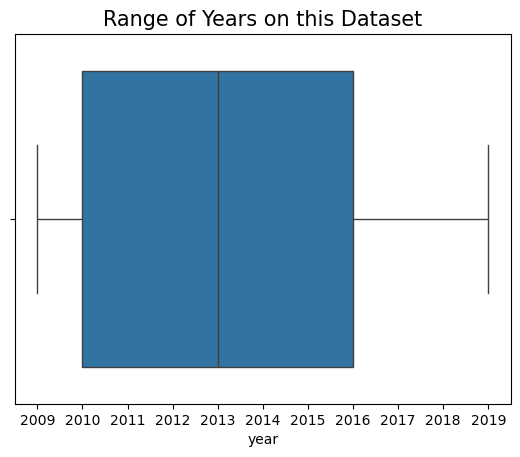

In [20]:
# ------------------------------------------------------------------------------------
print(f'   - Min Year: {df.year.min():.0f}\n   - Max Year: {df.year.max():.0f}')

# ------------------------------------------------------------------------------------
sns.boxplot(data=df, x='year')
plt.title('Range of Years on this Dataset', fontsize=15)
plt.xticks(list(range(2009, 2020)))
plt.show()

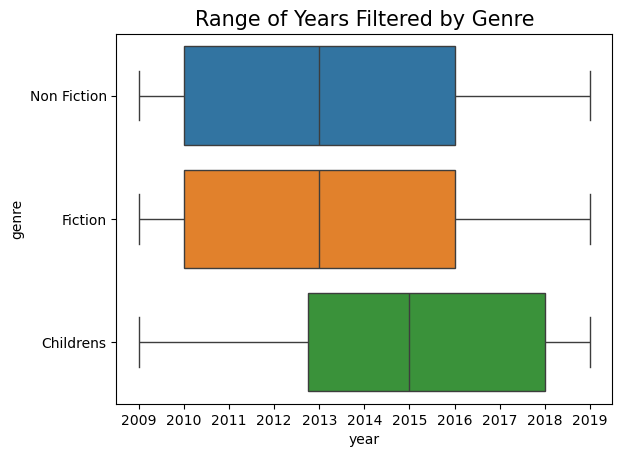

In [21]:
sns.boxplot(data=df, x='year', y='genre', hue='genre')
plt.title('Range of Years Filtered by Genre', fontsize=15)
plt.xticks(list(range(2009, 2020)))
plt.show()

<br><br>

---
---

## Lesson 3: Data Sumarization

In [22]:
df.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens


<br><br>

---

### Exploring Groups of Data

In [27]:
df[['genre', 'rating', 'year']].groupby('genre', as_index=False).mean()

,genre,rating,year
0,Childrens,4.780000,2015.075000
1,Fiction,4.570229,2013.022901
2,Non Fiction,4.598324,2013.513966


<br><br>

---

### 1. Aggregating Ungrouped Data - Standard Method

In [28]:
df[['rating', 'year']].agg(['mean', 'std', 'min', 'max'])

,rating,year
mean,4.608571,2013.508571
std,0.226941,3.284711
min,3.300000,2009.000000
max,4.900000,2019.000000


<br><br>

---

### 2. Specifying Aggregations for Columns

In [30]:
df.agg({'rating':['min', 'mean', 'std', 'max'],
        'year':['mean', 'median', 'std', 'var']})

,rating,year
min,3.300000,NaN
mean,4.608571,2013.508571
std,0.226941,3.284711
max,4.900000,NaN
median,NaN,2013.000000
var,NaN,10.789325


<br><br>

---

### 3. Named Summary Columns

In [31]:
df.groupby('genre').agg(
    mean_rating = ('rating', 'mean'),
    median_rating = ('rating', 'median'),
    std_rating = ('rating', 'std'),
    mean_year = ('year', 'mean'),
    median_year = ('year', 'median')
)   

,mean_rating,median_rating,std_rating,mean_year,median_year
genre,,,,,
Childrens,4.780000,4.8,0.122370,2015.075000,2015.0
Fiction,4.570229,4.6,0.281123,2013.022901,2013.0
Non Fiction,4.598324,4.6,0.179411,2013.513966,2013.0


<br><br>

---

### Visuzalizing Categorical Summaries

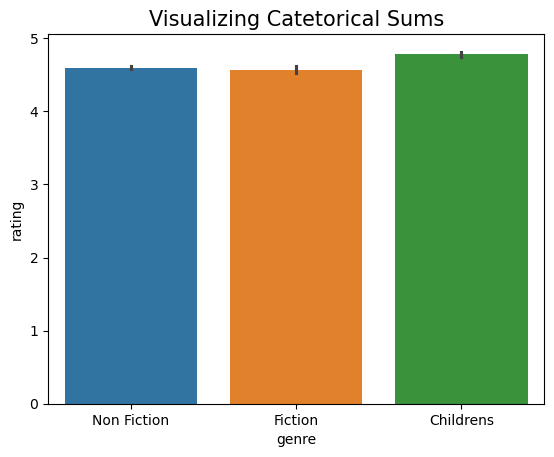

In [33]:
sns.barplot(data=df, x='genre', y='rating', hue='genre')
plt.title('Visualizing Catetorical Sums', fontsize=15)
plt.show()

 - In Seaborn, bar plots will automatically calculate the mean of a quantitative variable
   
 - In Seaborn, bar plots also show a 95% confidence interval for the mean as a vertical line on the top of each bar.

The results reinforce what we saw earlier: 
 - while Fiction books have the lowest rating, their ratings also have a little more variation.